In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# 1. 데이터 로드 및 결측치 제거 (Penguins는 결측치가 있어 처리가 필요함)
df = sns.load_dataset('penguins')
df = df.dropna()  # 분석의 편의를 위해 결측치가 있는 행 제거
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
# ---------------------------------------------------------
# 2. Profiling (데이터 요약 및 성격 파악)
# ---------------------------------------------------------
print("### 1. Data Profiling ###")

### 1. Data Profiling ###


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [6]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


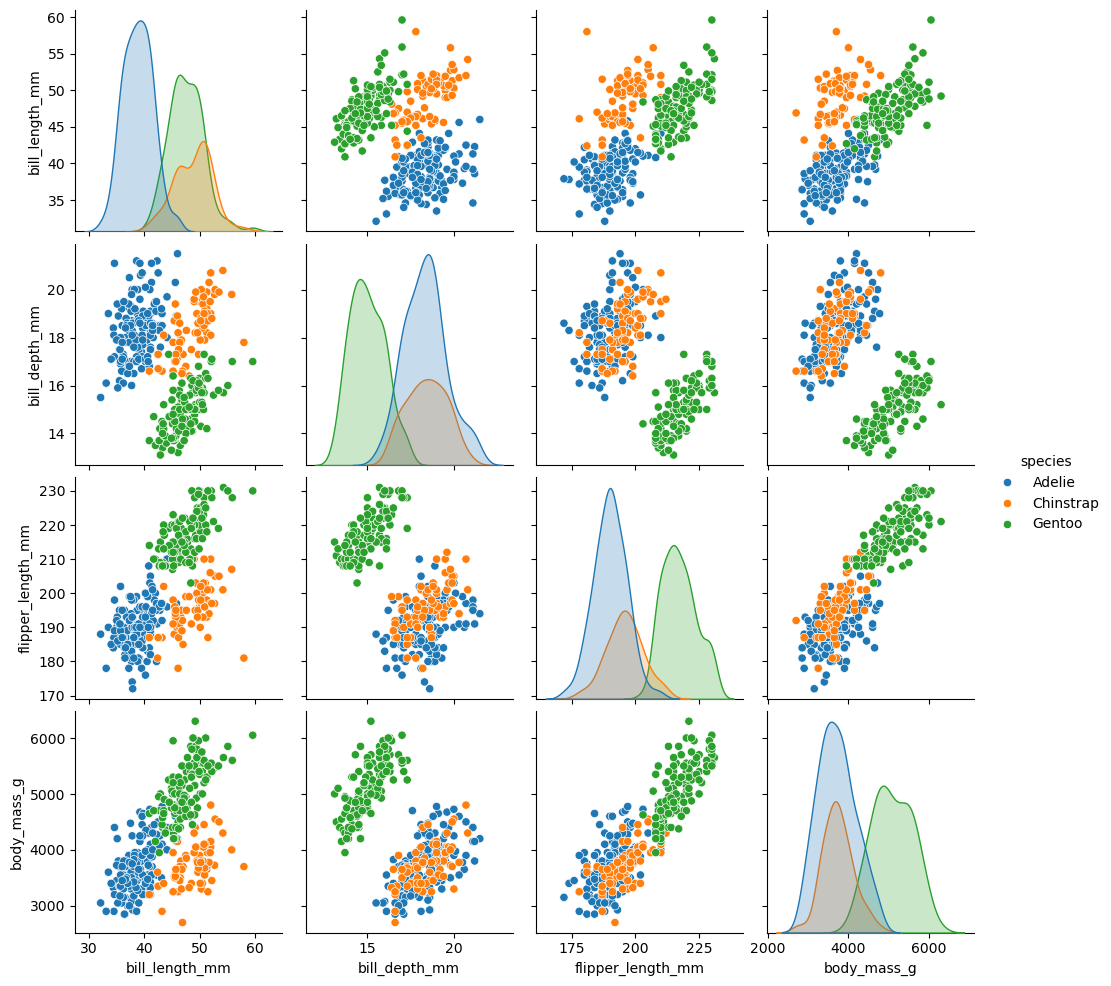

In [7]:
# 수치형 변수들의 분포와 종(Species)별 관계 시각화
sns.pairplot(df, hue='species', diag_kind='kde')
plt.show()

In [8]:
# ---------------------------------------------------------
# 3. 상관분석 (Correlation Analysis)
# ---------------------------------------------------------
print("\n### 2. Correlation Analysis ###")
# 수치형 데이터만 선택
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
corr


### 2. Correlation Analysis ###


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


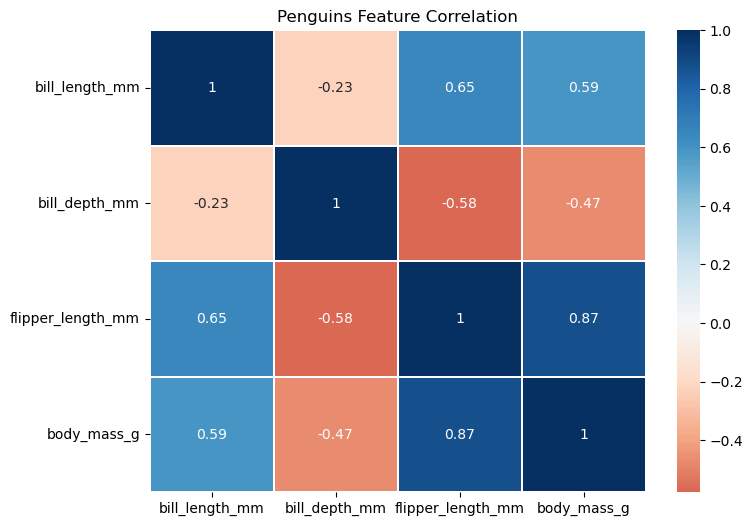

In [9]:
# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu', center=0, linewidths=0.1)
plt.title("Penguins Feature Correlation")
plt.show()

In [10]:
# ---------------------------------------------------------
# 4. 차이 검정 (t-test & ANOVA)
# ---------------------------------------------------------
print("\n### 3. Statistical Tests ###")

# [t-test] 성별(Male vs Female)에 따른 몸무게(body_mass_g) 차이
male_weight = df[df['sex'] == 'Male']['body_mass_g']
female_weight = df[df['sex'] == 'Female']['body_mass_g']
t_stat, p_val_t = stats.ttest_ind(male_weight, female_weight)
print(f"[t-test] Male vs Female (Body Mass) p-value: {p_val_t:.4f}")


### 3. Statistical Tests ###
[t-test] Male vs Female (Body Mass) p-value: 0.0000


In [11]:
# [ANOVA] 3가지 종(Adelie, Chinstrap, Gentoo) 간의 부리 길이(bill_length_mm) 차이
groups = [df[df['species'] == s]['bill_length_mm'] for s in df['species'].unique()]
f_stat, p_val_f = stats.f_oneway(*groups)
print(f"[ANOVA] Species vs Bill Length p-value: {p_val_f:.4f}")

[ANOVA] Species vs Bill Length p-value: 0.0000


In [12]:
# ---------------------------------------------------------
# 5. PCA (주성분 분석)
# ---------------------------------------------------------
print("\n### 4. PCA (Dimensionality Reduction) ###")
# 수치형 데이터 표준화
x = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
x_scaled = StandardScaler().fit_transform(x)

# 2개의 주성분으로 축소
pca = PCA(n_components=2)
pca_res = pca.fit_transform(x_scaled)
df_pca = pd.DataFrame(pca_res, columns=['PC1', 'PC2'])
df_pca['species'] = df['species'].values

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")


### 4. PCA (Dimensionality Reduction) ###
Explained variance ratio: [0.68633893 0.19452929]


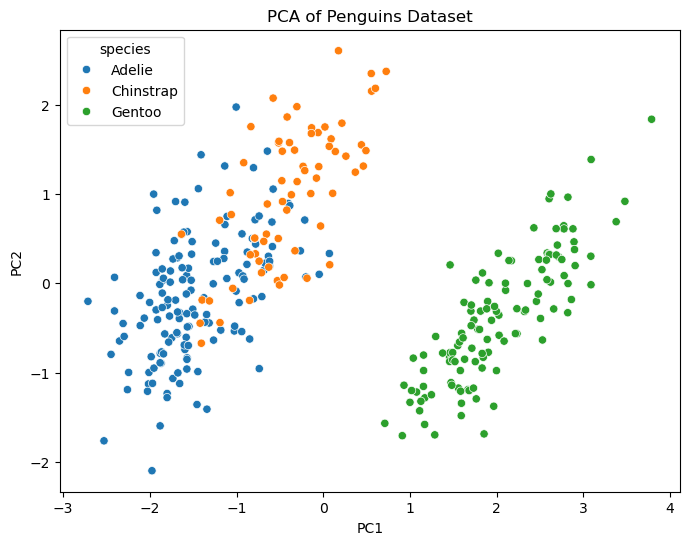

In [13]:
# PCA 결과 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='species', data=df_pca)
plt.title("PCA of Penguins Dataset")
plt.show()

In [14]:
# ---------------------------------------------------------
# 6. 군집분석 (Clustering - K-means)
# ---------------------------------------------------------
print("\n### 5. Cluster Analysis (K-means) ###")
# PCA로 축소된 데이터를 기반으로 3개 그룹 클러스터링
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(x_scaled)

# 실제 종과 군집 결과 비교 (Profiling의 일환)
ct = pd.crosstab(df['species'], df['cluster'])
print("Confusion Matrix (Species vs Cluster):")
print(ct)


### 5. Cluster Analysis (K-means) ###
Confusion Matrix (Species vs Cluster):
cluster      0    1   2
species                
Adelie     124    0  22
Chinstrap    5    0  63
Gentoo       0  119   0


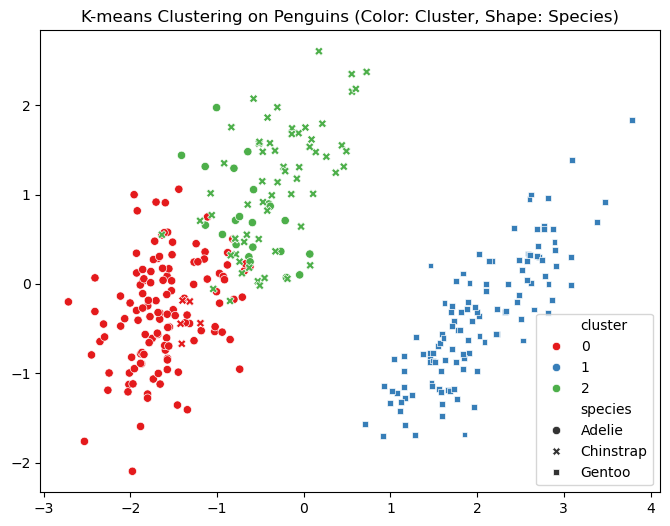

In [15]:
# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_res[:, 0], y=pca_res[:, 1], hue=df['cluster'], palette='Set1', style=df['species'])
plt.title("K-means Clustering on Penguins (Color: Cluster, Shape: Species)")
plt.show()

In [16]:
# end